## This notebook trains an SBERT model on the PAWS Dataset

In [1]:
#Importing required packages
import os
import sys
import time
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

sys.path.append(os.path.abspath(".."))

from src.sbert_models import (
    load_sbert_model,
    generate_embeddings,
    concatenate_embeddings
)

from src.classical_models import (
    train_logistic_regression,
    predict
)

from src.evaluate import (
    evaluate_classifier,
    compute_confusion_matrix
)

from src.utils import log_experiment

In [2]:
#Load the processed datasets
train = pd.read_csv(
    "../datasets/processed/classical/paws_train.csv"
)

validation = pd.read_csv(
    "../datasets/processed/classical/paws_validation.csv"
)

test = pd.read_csv(
    "../datasets/processed/classical/paws_test.csv"
)

In [3]:
#Loading sbert
model = load_sbert_model()
print(model)

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


In [4]:
#Generate embeddings
train_emb1 = generate_embeddings(
    model,
    train["sentence1"]
)

train_emb2 = generate_embeddings(
    model,
    train["sentence2"]
)

test_emb1 = generate_embeddings(
    model,
    test["sentence1"]
)

test_emb2 = generate_embeddings(
    model,
    test["sentence2"]
)

validation_emb1 = generate_embeddings(
    model,
    validation["sentence1"]
)

validation_emb2 = generate_embeddings(
    model,
    validation["sentence2"]
)

Batches:   0%|          | 0/1544 [00:00<?, ?it/s]

Batches:   0%|          | 0/1544 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

In [5]:
#Concatenate
X_train = concatenate_embeddings(
    train_emb1,
    train_emb2
)

X_validation = concatenate_embeddings(
    validation_emb1,
    validation_emb2
)

X_test = concatenate_embeddings(
    test_emb1,
    test_emb2
)

print(X_train.shape)

(49401, 768)


In [6]:
y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]

In [7]:
#Training a logistic regression model
start_time = time.perf_counter()

classifier = train_logistic_regression(
    X_train,
    y_train
)

end_time = time.perf_counter()

training_time = end_time - start_time

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 2.3294 seconds


In [8]:
#Predictions
start_time = time.perf_counter()

predictions, probabilities = predict(
    classifier,
    X_validation
)

end_time = time.perf_counter()

inference_time = end_time - start_time

print(f"Inference Time: {inference_time:.4f} seconds")

Inference Time: 0.0226 seconds


In [9]:
#Evaluation
metrics = evaluate_classifier(
    y_validation,
    predictions,
    probabilities
)

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.5586
Precision: 0.5027
Recall: 0.2116
F1: 0.2979
ROC-AUC: 0.5389


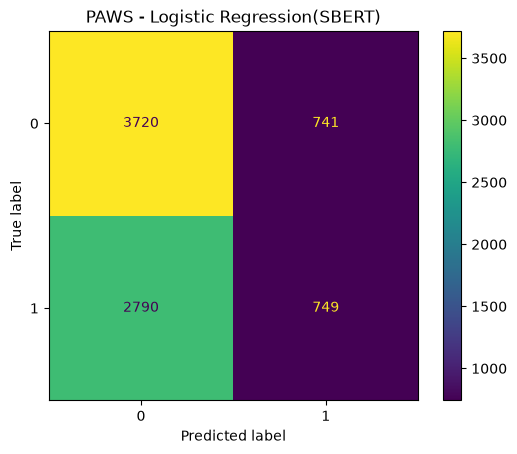

In [10]:
cm = compute_confusion_matrix(
    y_validation,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("PAWS - Logistic Regression(SBERT)")

plt.savefig(
    "../results/plots/paws_confusion_matrix(SBERT).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

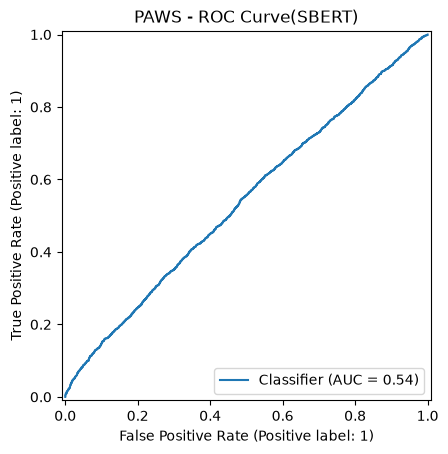

In [11]:
RocCurveDisplay.from_predictions(
    y_validation,
    probabilities
)

plt.title("PAWS - ROC Curve(SBERT)")

plt.savefig(
    "../results/plots/paws_roc_curve(SBERT).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
#Saving the results
predictions_df = validation.copy()

predictions_df["prediction"] = predictions
predictions_df["probability"] = probabilities

predictions_df.to_csv(
    "../results/predictions/paws_predictions(SBERT).csv",
    index=False
)

predictions_df.head()

,id,sentence1,sentence2,label,prediction,probability
0,1,bradd crellin represented barla cumbria on a t...,bradd crellin also represented barla great bri...,0,0,0.480866
1,2,they were there to enjoy us and they were ther...,they were there for us to enjoy and they were ...,1,0,0.382984
2,3,"after the end of the war in june 1902 , higgin...","in august , after the end of the war in june 1...",1,0,0.389912
3,4,from the merger of the four rivers council and...,shawnee trails council was formed from the mer...,1,0,0.424897
4,5,the group toured extensively and became famous...,the group toured extensively and was famous in...,1,1,0.520927


In [13]:
#Saving the predictions
metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    "../results/metrics/paws_logreg_metrics(SBERT).csv",
    index=False
)

metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.558625,0.502685,0.211642,0.297872,0.538899


In [14]:
#Saving the model
from src.utils import save_model

save_model(
    classifier,
    "../models/sbert/paws_classifier.pkl"
)

In [15]:
from datetime import date
from src.utils import log_experiment

experiment = {
    "Experiment ID": "EXP-004",
    "Date": date.today().isoformat(),
    "Phase": "SBERT Baseline",
    "Model": "SBERT + Logistic Regression",
    "Dataset": "PAWS",
    "Train Split": len(train),
    "Validation Split": len(validation),
    "Test Split": len(test),
    "Batch Size": 32,
    "Learning Rate": "N/A",
    "Epochs": "N/A",
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1": metrics["F1"],
    "ROC-AUC": metrics["ROC-AUC"],
    "BLEU": "N/A",
    "ROUGE": "N/A",
    "BERTScore": "N/A",
    "Train Time": training_time,
    "Inference Time": inference_time,
    "Notes": "all-MiniLM-L6-v2 (384d), concatenated embeddings",
    "Status": "Completed"
}

log_experiment(
    "../logs/experiments.xlsx",
    experiment
)

In [16]:
from src.reporting import ReportGenerator

report = ReportGenerator()

comparison = report.generate_model_comparison()

comparison

,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time,Inference Time
0,Logistic Regression,MRPC,0.727941,0.723404,0.974910,0.830534,0.675863,0.036566,0.000996
2,Logistic Regression,PAWS,0.556500,0.497691,0.274089,0.353499,0.548097,0.695119,0.009175
1,Logistic Regression,QQP,0.767549,0.722849,0.597850,0.654434,0.836436,3.161926,0.008341
3,SBERT + Logistic Regression,MRPC,0.629902,0.720690,0.749104,0.734622,0.561279,0.793760,0.003465
5,SBERT + Logistic Regression,PAWS,0.558625,0.502685,0.211642,0.297872,0.538899,2.329359,0.022624
4,SBERT + Logistic Regression,QQP,0.717462,0.662474,0.474169,0.552723,0.750352,36.028248,0.154764
